In [1]:
import bioinfoLib as binf
import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import scanpy as sc
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from vae_v2 import *

sc.set_figure_params(figsize=(5, 5))

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Seed set to 42


In [2]:
data = sc.read_h5ad("../data/adata_timeseries_all_v3.h5ad")
binf.scr.qc.normalize_and_select_hvg(data)
data_1 = data[data.obs["sample_labels"] == "72h-1"].copy()
data_2 = data[data.obs["sample_labels"] == "72h-2"].copy()
sc.pp.subsample(data_1, n_obs=6000)
sc.pp.subsample(data_2, n_obs=6000)
data = sc.concat([data_1, data_2])
sc.pp.pca(data)
sc.pp.neighbors(data, method="gauss", n_neighbors=25)
sc.tl.diffmap(data)
data_1 = data[data.obs["sample_labels"] == "72h-1"].copy()
data_2 = data[data.obs["sample_labels"] == "72h-2"].copy()
x_l_1 = data_1.obsm["X_diffmap"][:, 1:]
x_l_2 = data_2.obsm["X_diffmap"][:, 1:]
x_e_1 = np.dot(data_1.X.toarray(), data_1.varm["PCs"])
x_e_2 = np.dot(data_2.X.toarray(), data_2.varm["PCs"])
c1 = np.repeat(0, x_l_1.shape[0])
c2 = np.repeat(1, x_l_2.shape[0])

# sc.pp.pca(data_1, n_comps=200)
# sc.pp.pca(data_2, n_comps=200)
# sc.pp.neighbors(data_1, method="gauss", n_neighbors=25)
# sc.pp.neighbors(data_2, method="gauss", n_neighbors=25)
# sc.tl.diffmap(data_1)
# sc.tl.diffmap(data_2)

# x1 = data_1.obsm["X_diffmap"][:, 1:]
# x2 = data_2.obsm["X_diffmap"][:, 1:]

# c1 = np.repeat(0, x1.shape[0])
# c2 = np.repeat(1, x2.shape[0])

counts layer is not available and X is not log1p transformed. Copy X to counts before normalization
no raw in adata, so save X to raw before computing hvg


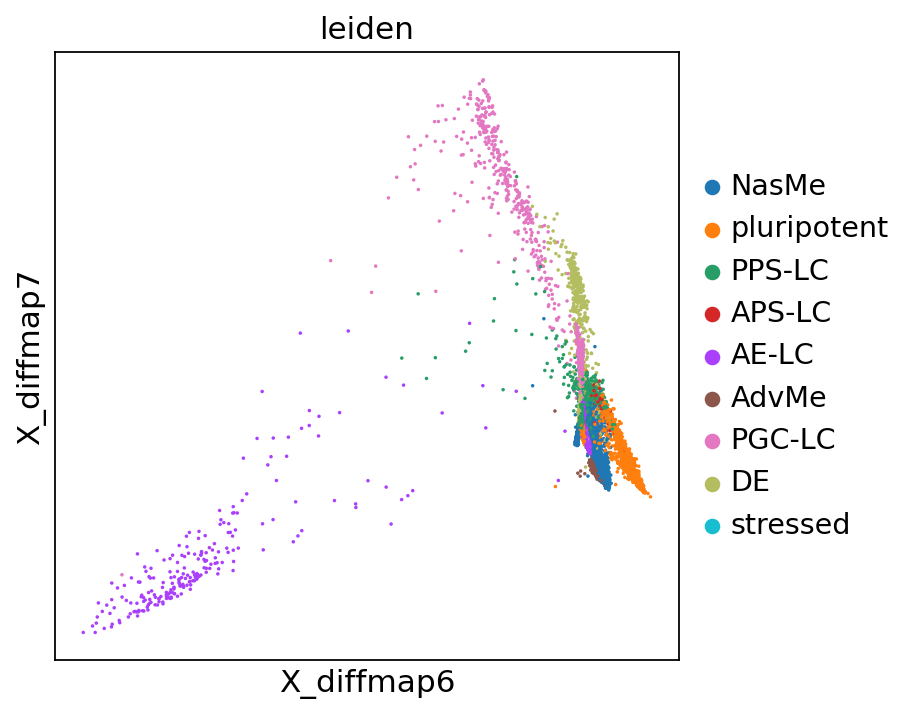

In [3]:
sc.pl.embedding(data, basis="X_diffmap", components="6,7", color="leiden")

In [4]:
x_e = np.concatenate([x_e_1, x_e_2])
x_l = np.concatenate([x_l_1, x_l_2])
c = np.concatenate([c1, c2])
x_e_tensor = torch.FloatTensor(x_e)
x_l_tensor = torch.FloatTensor(x_l)
c_tensor = torch.LongTensor(c)
c_tensor = F.one_hot(c_tensor, num_classes=2).float()
dataset = TensorDataset(x_e_tensor, x_l_tensor, c_tensor)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

In [ ]:
input_dim = x_e.shape[1] + x_l.shape[1]
condition_dim = 2
# Initialize model with correct dimensions
encoder = Encoder(
    input_dim=input_dim,
    condition_dim=condition_dim,
    input_e_dim=x_e.shape[1],
    hidden_dim=16 * 80,
    latent_dim=10,
)
decoder = Decoder(
    output_dim=input_dim,
    condition_dim=condition_dim,
    hidden_dim=16 * 80,
    latent_dim=10,
)
model = VAE(encoder, decoder, x_e.shape[1], x_l.shape[1], kl_weight=1.0, x_l_weight=2)

# Initialize trainer and fit
trainer = pl.Trainer(accelerator="gpu", max_epochs=2000)
trainer.fit(model, dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type    | Params | Mode 
--------------------------------------------
0 | Encoder | Encoder | 3.5 M  | train
1 | Decoder | Decoder | 3.5 M  | train
--------------------------------------------
7.0 M     Trainable params
0         Non-trainable par

Epoch 65:  67%|██████▋   | 16/24 [00:00<00:00, 41.84it/s, v_num=85, loss=-452.] 


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [6]:
c_pred = torch.zeros_like(c_tensor)
c_pred[:, 1] = 1
out = model(x_e_tensor, x_l_tensor, c_pred)[0].detach().numpy()

In [12]:
out.shape

(12000, 64)

In [77]:
out_z = model(x_e_tensor, x_l_tensor, c_tensor)[3].detach().numpy()
# x_hat_mean = model.Decoder(out_z, c_pred)[0].detach().numpy()

In [78]:
data.obsm["X_z"] = out_z

In [79]:
sc.pp.neighbors(data, use_rep="X_z", method="gauss", n_neighbors=30)
sc.tl.diffmap(data)

In [36]:
sc.tl.umap(data)

/home/stanfish/Git/vae/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [98]:
data.obsm["X_diffmap"] = out[:, 2000:]

In [7]:
data = sc.concat([data_1, data_2])
del data.obsm
data.obsm["X_vae"] = out[:, 50:]

In [26]:
x_hat_pred = model.Decoder.forward(out, c_pred)[0]

TypeError: expected Tensor as element 0 in argument 0, but got numpy.ndarray

In [11]:
data.obsm["X_diffmap_map"] = x_hat_pred[:, 2000:].detach().numpy()

In [24]:
sc.pp.neighbors(data, use_rep="X_vae")
sc.tl.umap(data)

/home/stanfish/Git/vae/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
sc.pl.umap(data, color="leiden")

KeyError: "Could not find 'umap' or 'X_umap' in .obsm"

/home/stanfish/Git/vae/.venv/lib/python3.12/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/stanfish/Git/vae/.venv/lib/python3.12/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


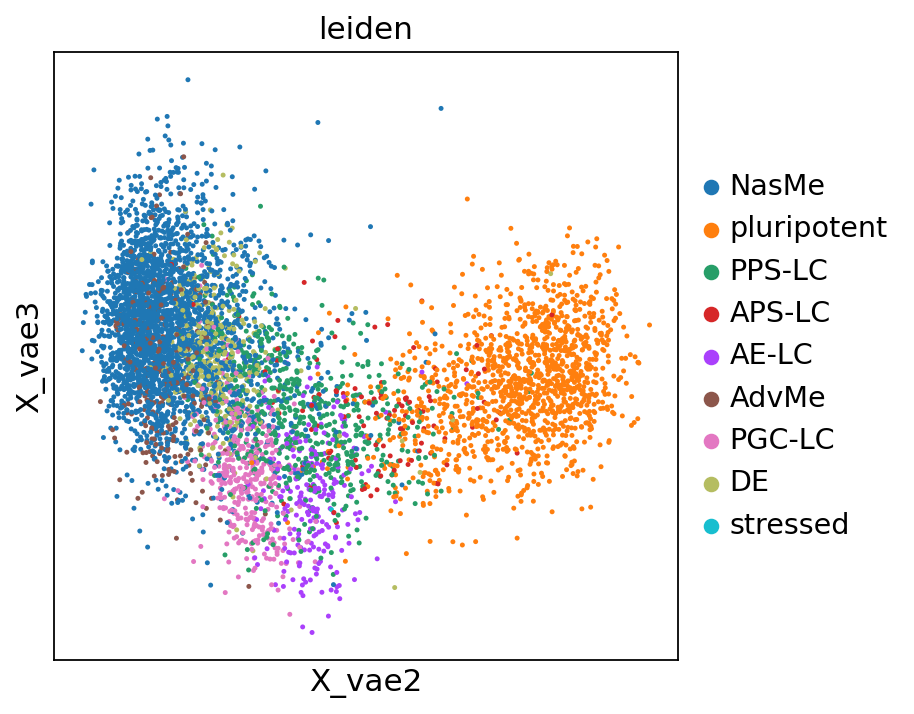

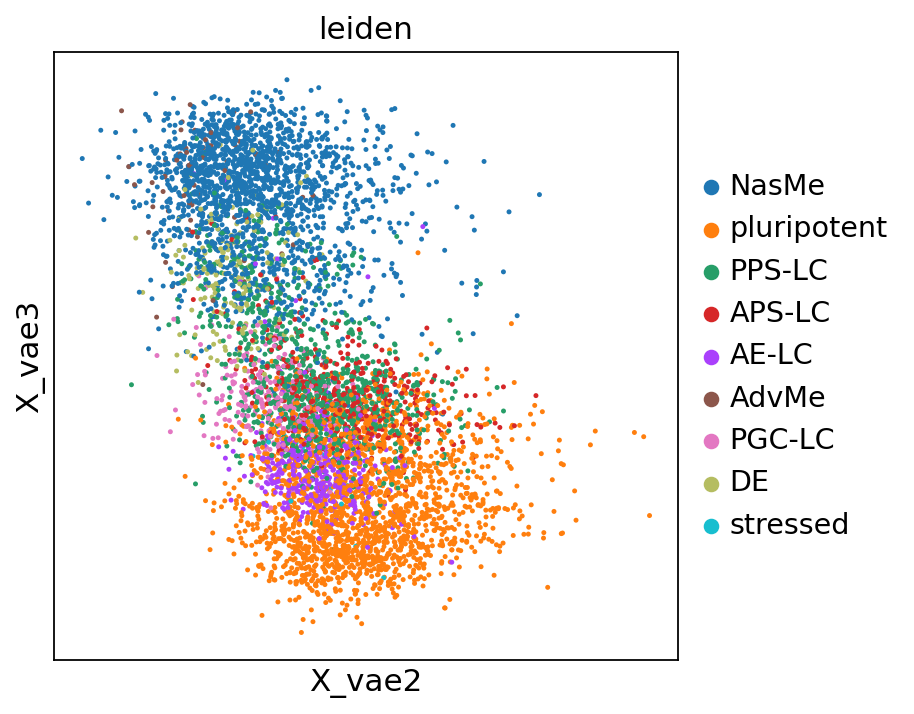

In [9]:
# ax = sc.pl.embedding(
#     data_1,
#     basis="X_diffmap",
#     color=["leiden"],
#     # ax=ax,
#     components="4,5",
#     show=False,
# )
comp = "2,3"
ax = sc.pl.embedding(
    data[data.obs["sample_labels"] == "72h-1"],
    basis="X_vae",
    color=["leiden"],
    # ax=ax,
    components=comp,
    show=False,
    # size=10,
)
sc.pl.embedding(
    data[data.obs["sample_labels"] == "72h-2"],
    basis="X_vae",
    color=["leiden"],
    # ax=ax,
    components=comp,
    # size=10,
    # show=False,
)

In [36]:
sc.pl.embedding(
    data,
    basis="X_diffmap",
    color="leiden",
    components="2,3",
)

KeyError: "Could not find 'X_diffmap' or 'X_X_diffmap' in .obsm"

In [41]:
x1_pred = out[c_tensor[:, 0].detach().numpy() == 1, :]
x2_pred = out[c_tensor[:, 1].detach().numpy() == 1, :]
data_1.obsm["X_diffmap_pred"] = x1_pred
data_2.obsm["X_diffmap_pred"] = x2_pred

In [22]:
out.shape

(12000, 14)

In [20]:
c_tensor

tensor([[1., 0.],
        [1., 0.],
        [1., 0.],
        ...,
        [0., 1.],
        [0., 1.],
        [0., 1.]])

<Axes: title={'center': 'leiden'}, xlabel='X_diffmap_pred1', ylabel='X_diffmap_pred2'>

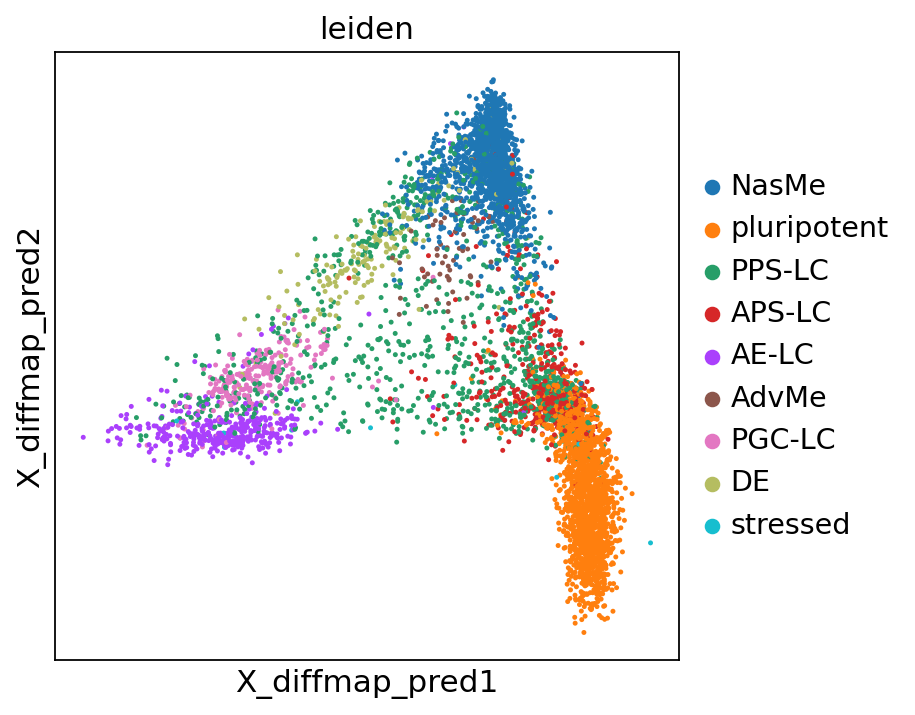

In [50]:
fig, ax = plt.subplots(figsize=(5, 5))
# sc.pl.embedding(
#     data_2,
#     basis="X_diffmap",
#     color="leiden",
#     ax=ax,
#     components="2,5",
#     show=False,
# )
sc.pl.embedding(
    data_2,
    basis="X_diffmap_pred",
    color="leiden",
    ax=ax,
    components="1,2",
    show=False,
)
# sc.pl.embedding(
#     data_1,
#     basis="X_diffmap_pred",
#     color="leiden",
#     ax=ax,
#     components="1,2",
#     show=False,
# )
# # ax.scatter(x2_pred[:, 1], x2_pred[:, 2], s=1, color="blue")
# ax.scatter(x1_pred[:, 1], x1_pred[:, 2], s=1, color="green")